In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=0e6f6145fb2aa07828b114a52835e0fa9e7d58e496e08e518c2c3ce60e9392b4
  Stored in directory: /root/.cache/pip/wheels/05/bd/e2/0c0eecf3c26b6cdb231b5656d53905bddc8090d69619d57e6b
Successfully built grad-cam


In [2]:
import os
if not os.path.exists('/kaggle/working/MIRAGE'):
    print("Cloning MIRAGE repository...")
    os.system('git clone -q https://github.com/j-morano/MIRAGE.git /kaggle/working/MIRAGE')

os.makedirs('/kaggle/working/MIRAGE/__weights', exist_ok=True)

if not os.path.exists('/kaggle/working/MIRAGE/__weights/MIRAGE-Base.pth'):
    print("Downloading MIRAGE-Base weights...")
    os.system('wget -q -O /kaggle/working/MIRAGE/__weights/MIRAGE-Base.pth '
              'https://github.com/j-morano/MIRAGE/releases/download/weights/MIRAGE-Base.pth')
    print("Download complete")

Cloning MIRAGE repository...
Download complete


In [4]:
# Standard library
import sys, glob, random, warnings, json
from pathlib import Path
from copy import deepcopy
from concurrent.futures import ThreadPoolExecutor

# System setup
sys.path.insert(0, '/kaggle/working/MIRAGE')

# Data
import numpy as np
import pandas as pd
import scipy.stats
from PIL import Image
from tqdm import tqdm

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: models and preprocessing
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn: metrics
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    auc, 
    roc_auc_score,
    matthews_corrcoef, 
    balanced_accuracy_score
)

# PyTorch and extensions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Custom modules
from mirage_wrapper import miragecls_factory

# Configurations
warnings.filterwarnings('ignore')

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

G = torch.Generator()
G.manual_seed(SEED)

def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


---
&nbsp;

## **1. Data Loading & Filtering**

In [6]:
DATASET_PATH = '/kaggle/input/datasets/susannamazzocchi/rasti-images/rasti_images'

imgs_raw = glob.glob(DATASET_PATH + '/**/*.*', recursive=True)
imgs_raw = [f for f in imgs_raw if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))]
print(f'Total images found (raw): {len(imgs_raw)}')

Total images found (raw): 3348


In [7]:
TARGET_SIZE = (496, 512)

def is_valid_oct(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
            if not (0.8 < w / h < 1.2):
                return False
            return (w, h) == TARGET_SIZE
    except:
        return False

with ThreadPoolExecutor(max_workers=8) as executor:
    mask = list(tqdm(executor.map(is_valid_oct, imgs_raw),
                     total=len(imgs_raw), desc='Filtering OCT images'))

imgs = [p for p, keep in zip(imgs_raw, mask) if keep]
n_removed = len(imgs_raw) - len(imgs)

print(f'Raw         : {len(imgs_raw)}')
print(f'After filter: {len(imgs)}  (removed {n_removed}, target size={TARGET_SIZE})')

Filtering OCT images: 100%|██████████| 3348/3348 [00:05<00:00, 664.61it/s]

Raw         : 3348
After filter: 3231  (removed 117, target size=(496, 512))


In [8]:
records = []
for path in imgs:
    p = Path(path)
    rel = p.relative_to(DATASET_PATH)
    parts = rel.parts
    if len(parts) >= 4:
        records.append({
            'path':       str(path),
            'label':      parts[0],
            'patient_id': parts[1],
            'date':       parts[2]
        })

df = pd.DataFrame(records)
df['label_clean'] = df['label'].str.replace(' Part1', '').str.replace(' Part2', '')

unique_labels   = sorted(df['label_clean'].unique())
class_mapping   = {name: idx for idx, name in enumerate(unique_labels)}
inverse_mapping = {v: k for k, v in class_mapping.items()}
class_names     = [inverse_mapping[i] for i in range(len(class_mapping))]
df['label_idx'] = df['label_clean'].map(class_mapping)

print(f'Classes : {class_names}')
print(f'Total   : {len(df)} images')
display(df.head())

Classes : ['AMD', 'DME', 'Normal']
Total   : 3231 images


,path,label,patient_id,date,label_clean,label_idx
0,/kaggle/input/datasets/susannamazzocchi/rasti-...,AMD Part1,AMD (11).E2E,2- 25- 2017 4- 44- 26 PM,AMD,0
1,/kaggle/input/datasets/susannamazzocchi/rasti-...,AMD Part1,AMD (11).E2E,2- 25- 2017 4- 44- 26 PM,AMD,0
2,/kaggle/input/datasets/susannamazzocchi/rasti-...,AMD Part1,AMD (11).E2E,2- 25- 2017 4- 44- 26 PM,AMD,0
3,/kaggle/input/datasets/susannamazzocchi/rasti-...,AMD Part1,AMD (11).E2E,2- 25- 2017 4- 44- 26 PM,AMD,0
4,/kaggle/input/datasets/susannamazzocchi/rasti-...,AMD Part1,AMD (11).E2E,2- 25- 2017 4- 44- 26 PM,AMD,0


,Category,Patients,Images,Images_per_Patient
0,AMD,18,486,27.0
1,DME,49,1117,22.8
2,Normal,50,1628,32.6


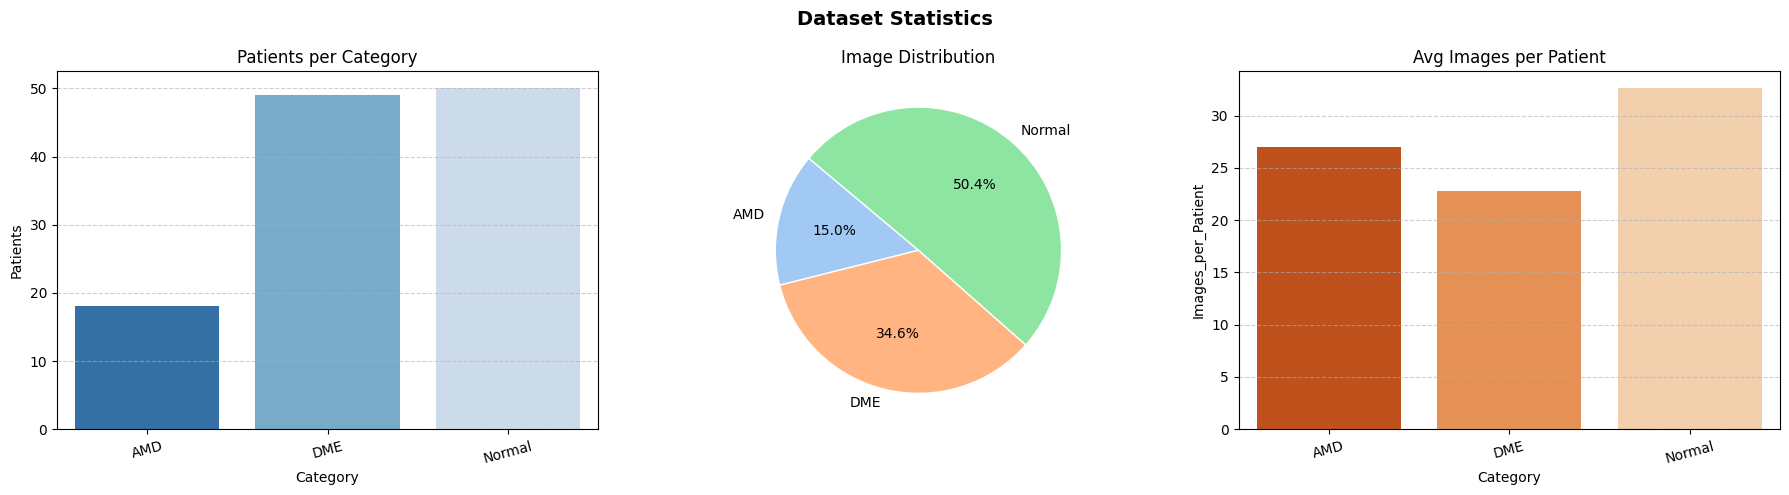

In [9]:
agg = (
    df.groupby('label_clean')
    .agg(Patients=('patient_id', 'nunique'), Images=('path', 'count'))
    .reset_index().rename(columns={'label_clean': 'Category'})
)
agg['Images_per_Patient'] = (agg['Images'] / agg['Patients']).round(1)
display(agg)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Statistics', fontsize=14, fontweight='bold')

sns.barplot(data=agg, x='Category', y='Patients', palette='Blues_r', ax=axes[0])
axes[0].set_title('Patients per Category')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[1].pie(agg['Images'], labels=agg['Category'], autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=140,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Image Distribution')

sns.barplot(data=agg, x='Category', y='Images_per_Patient', palette='Oranges_r', ax=axes[2])
axes[2].set_title('Avg Images per Patient')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---
&nbsp;

## **2. Dataset & Preprocessing**

In [12]:
class MinMaxNorm:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        mn, mx = x.min(), x.max()
        if mx - mn < 1e-8:
            return torch.zeros_like(x)
        return (x - mn) / (mx - mn)


class OCTDatasetMIRAGE(Dataset):
    def __init__(self, dataframe, augment: bool = False):
        self.df      = dataframe.reset_index(drop=True)
        self.augment = augment
        self.norm    = MinMaxNorm()
        self.aug     = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([T.RandomRotation(degrees=10)], p=0.5),
            T.RandomApply([
                T.RandomAffine(
                    degrees=0,
                    translate=(0.1, 0.1),
                    scale=(0.9, 1.1),
                    shear=5,
                    interpolation=T.InterpolationMode.BILINEAR,
                    fill=0
                )
            ], p=0.5),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('L')
        img = img.resize((512, 512), Image.Resampling.LANCZOS)
        x   = torch.tensor(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)
        x   = self.norm(x)
        if self.augment:
            x = self.aug(x)
            x = self.norm(x)
        return x, int(row['label_idx'])

Shape  : (1, 512, 512)
Range  : [0.0000, 1.0000]
Label  : Normal


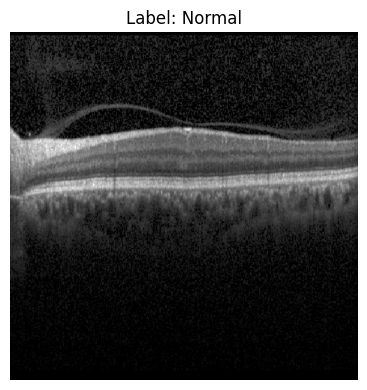

In [13]:
check_ds = OCTDatasetMIRAGE(df.sample(1, random_state=0).reset_index(drop=True))
img_t, lbl = check_ds[0]

print(f'Shape  : {tuple(img_t.shape)}')
print(f'Range  : [{img_t.min():.4f}, {img_t.max():.4f}]')
print(f'Label  : {inverse_mapping[lbl]}')

plt.figure(figsize=(4, 4))
plt.imshow(img_t.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
plt.title(f'Label: {inverse_mapping[lbl]}')
plt.axis('off')
plt.tight_layout()
plt.show()

---
&nbsp;

## **3. Patient-Aware Data Splitting**

In [15]:
y = df['label_idx'].values

sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
train_idx, temp_idx = next(sgkf.split(df, y, df['patient_id']))
df_train = df.iloc[train_idx]
df_temp  = df.iloc[temp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
val_idx, test_idx = next(sgkf2.split(df_temp, df_temp['label_idx'], df_temp['patient_id']))
df_val  = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

total = len(df)
split_summary = pd.DataFrame({
    'Split':    ['Train', 'Val', 'Test', 'Total'],
    'Images':   [len(df_train), len(df_val), len(df_test), total],
    'Patients': [
        df_train['patient_id'].nunique(),
        df_val['patient_id'].nunique(),
        df_test['patient_id'].nunique(),
        df['patient_id'].nunique()
    ],
    'Pct': [
        f"{len(df_train)/total*100:.1f}%",
        f"{len(df_val)/total*100:.1f}%",
        f"{len(df_test)/total*100:.1f}%",
        '100%'
    ]
})
display(split_summary)

,Split,Images,Patients,Pct
0,Train,2093,77,64.8%
1,Val,585,21,18.1%
2,Test,553,19,17.1%
3,Total,3231,117,100%


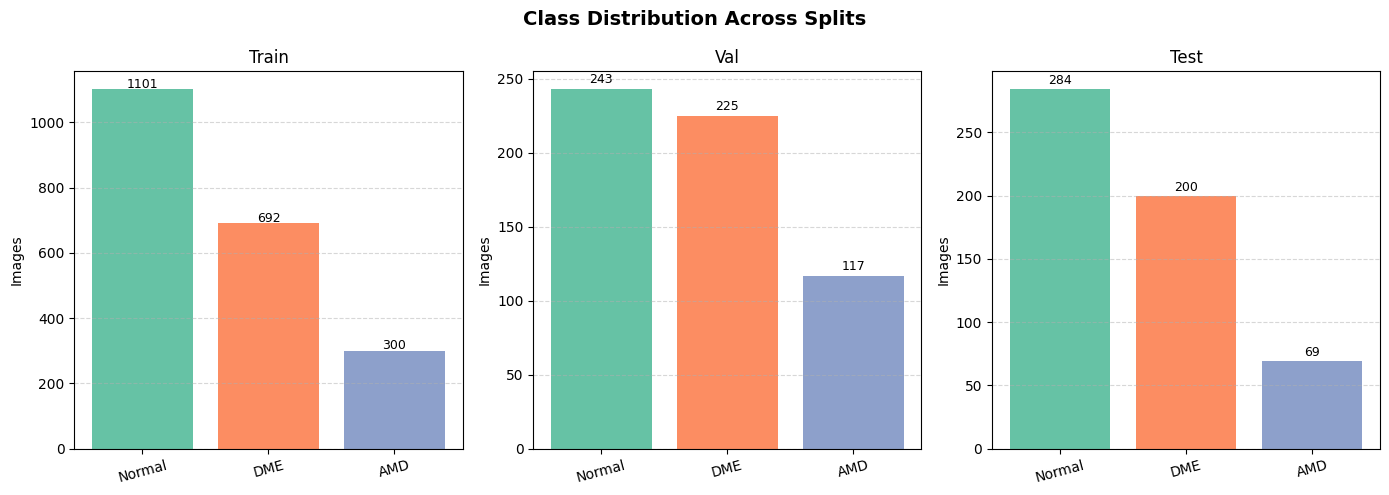

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold')

splits = {'Train': df_train, 'Val': df_val, 'Test': df_test}
for ax, (name, dframe) in zip(axes, splits.items()):
    counts = dframe['label_clean'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('Set2', len(counts)))
    ax.set_title(name)
    ax.set_ylabel('Images')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 4, str(v),
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
&nbsp;

## **4. Data Augmentation & DataLoaders**

In [17]:
y_train       = df_train['label_idx'].values
cw            = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(cw, dtype=torch.float).to(DEVICE)

BATCH_SIZE   = 16
NUM_WORKERS  = 2
NUM_CLASSES  = len(class_names)

train_dataset = OCTDatasetMIRAGE(df_train, augment=True)
val_dataset   = OCTDatasetMIRAGE(df_val,   augment=False)
test_dataset  = OCTDatasetMIRAGE(df_test,  augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=G
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train  : {len(train_dataset):>5} images')
print(f'Val    : {len(val_dataset):>5} images')
print(f'Test   : {len(test_dataset):>5} images')
print(f'Class weights: {cw.round(3)}')

Train  :  2093 images
Val    :   585 images
Test   :   553 images
Class weights: [2.326 1.008 0.634]


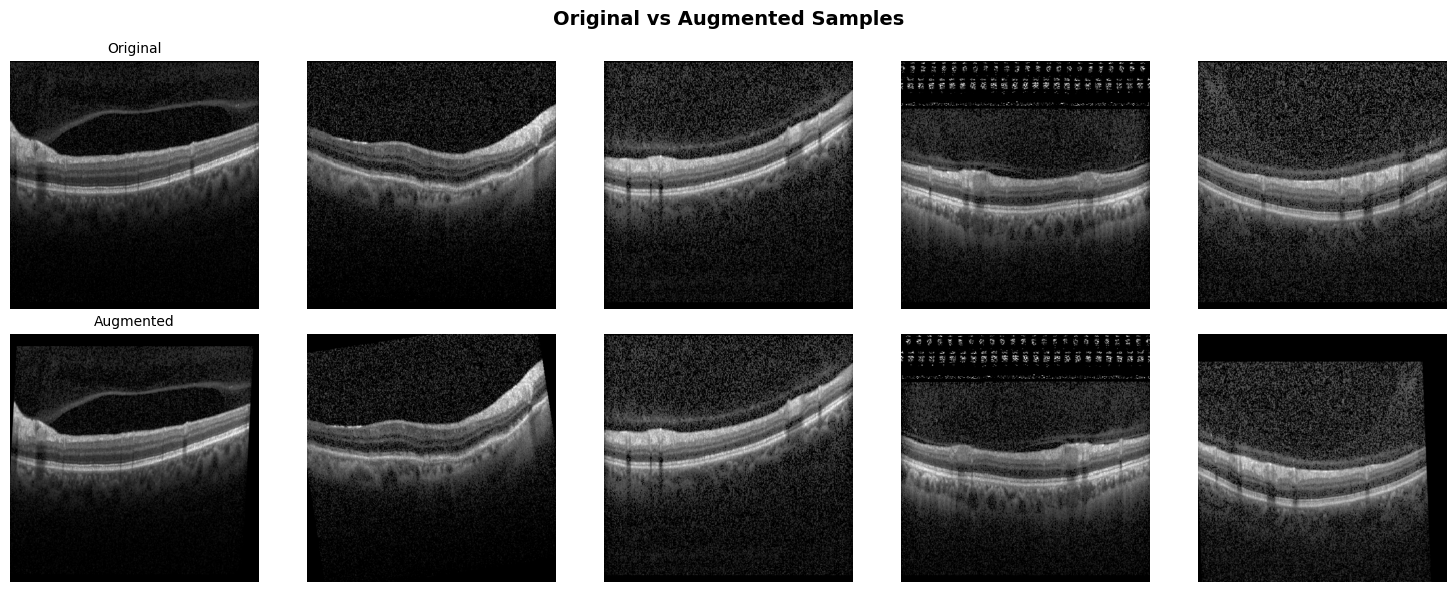

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Original vs Augmented Samples', fontsize=14, fontweight='bold')

sample_indices = random.sample(range(len(df_train)), 5)
df_sample = df_train.iloc[sample_indices].reset_index(drop=True)
orig_ds = OCTDatasetMIRAGE(df_sample, augment=False)
aug_ds  = OCTDatasetMIRAGE(df_sample, augment=True)

for i in range(5):
    img_o, lbl_o = orig_ds[i]
    img_a, _     = aug_ds[i]
    axes[0, i].imshow(img_o.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)
    axes[1, i].imshow(img_a.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Augmented', fontsize=10)

plt.tight_layout()
plt.show()

---
&nbsp;

## **5. MIRAGE Architecture**

MIRAGE is a multimodal foundation model based on ViT, pretrained via multi-task masked autoencoding on large-scale paired retinal OCT/SLO data (Morano et al., *npj Digital Medicine*, 2025). I used `MIRAGEClsGlobal`, which pools the mean of all patch token embeddings and feeds them into a linear classification head.

In [19]:
WEIGHTS_PATH = '/kaggle/working/MIRAGE/__weights/MIRAGE-Base.pth'
POOL         = 'global'

model = miragecls_factory[POOL](
    num_classes=NUM_CLASSES,
    input_size=512,
    patch_size=32,
    modalities='bscan',
    weights=WEIGHTS_PATH,
    device=str(DEVICE)
)
model = model.to(DEVICE)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Architecture  : MIRAGE-Base (ViT-B/32)')
print(f'Pool strategy : {POOL}')
print(f'Embed dim     : {model.embed_dim}')
print(f'Total params  : {n_total:,}')
print(f'Trainable     : {n_train:,}')
print(f'Classes       : {class_names}')

Creating model: pretrain_multimae_base for inputs ['bscan'] and outputs ['bscan', 'slo', 'bscanlayermap']
Image size: (512, 512), Patch size: (32, 32)
  Missing keys: 0
  Unexpected keys: 154
  Embedding dimension: 768
Architecture  : MIRAGE-Base (ViT-B/32)
Pool strategy : global
Embed dim     : 768
Total params  : 86,042,883
Trainable     : 85,846,275
Classes       : ['AMD', 'DME', 'Normal']


---
&nbsp;

## **6. Training**

Two-phase strategy: 

• **Phase 1** freezes the ViT backbone and trains only the classification head (linear probing, lr=1e-3). 

• **Phase 2** unfreezes all weights for full fine-tuning (lr=1e-5). Both phases use AdamW, cosine annealing, and early stopping on validation balanced accuracy.

In [20]:
class EarlyStopping:
    def __init__(self, patience: int = 10, delta: float = 1e-3, mode: str = 'max'):
        self.patience = patience
        self.delta    = delta
        self.mode     = mode
        self.best     = None
        self.counter  = 0
        self.stop     = False

    def __call__(self, value: float) -> bool:
        if self.best is None:
            self.best = value
            return True
        improved = (value > self.best + self.delta) if self.mode == 'max' \
                   else (value < self.best - self.delta)
        if improved:
            self.best    = value
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            probs   = torch.softmax(outputs, dim=1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
            all_preds.append(outputs.argmax(1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)
    bacc   = balanced_accuracy_score(y_true, y_pred)
    return total_loss / total, correct / total, bacc, y_true, y_pred, y_prob

### **Phase 1: Linear Probing**

In [21]:
for name, param in model.named_parameters():
    param.requires_grad = 'head.' in name or name == 'norm.weight' or name == 'norm.bias'

n_train_lp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters (LP): {n_train_lp:,}')

LR_LP    = 1e-3
WD       = 1e-2
EPOCHS   = 50
PATIENCE = 10

criterion   = nn.CrossEntropyLoss(weight=class_weights)
optimizer   = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_LP, weight_decay=WD
)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-8)
early_stop  = EarlyStopping(patience=PATIENCE, delta=1e-3, mode='max')

history_lp  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_bacc': [], 'lr': []}
best_state  = None

for epoch in tqdm(range(EPOCHS), desc='Phase 1 — LP'):
    tr_loss, tr_acc                        = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_bacc, _, _, _      = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    history_lp['train_loss'].append(tr_loss)
    history_lp['val_loss'].append(vl_loss)
    history_lp['train_acc'].append(tr_acc)
    history_lp['val_acc'].append(vl_acc)
    history_lp['val_bacc'].append(vl_bacc)
    history_lp['lr'].append(optimizer.param_groups[0]['lr'])
    if early_stop(vl_bacc):
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_val_loss_lp = vl_loss
    if early_stop.stop:
        print(f'Early stopping at epoch {epoch + 1}')
        break
model.load_state_dict(best_state)
print(f'Best Val BAcc (LP): {early_stop.best:.4f}')

Trainable parameters (LP): 3,843


Phase 1 — LP:   0%|          | 0/50 [00:00<?, ?it/s]

bscan 256
> Token distribution: {'bscan': 1.0}


Phase 1 — LP:  86%|████████▌ | 43/50 [27:27<04:28, 38.32s/it]

Early stopping at epoch 44
Best Val BAcc (LP): 0.9417


### **Phase 2: Full Fine-Tuning**

In [22]:
for param in model.parameters():
    param.requires_grad = True

n_train_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters (FT): {n_train_ft:,}')

LR_FT       = 1e-5

optimizer_ft  = optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=WD)
scheduler_ft  = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS, eta_min=1e-8)
early_stop_ft = EarlyStopping(patience=PATIENCE, delta=1e-3, mode='max')

history_ft = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_bacc': [], 'lr': []}

for epoch in tqdm(range(EPOCHS), desc='Phase 2 — FT'):
    tr_loss, tr_acc                        = train_epoch(model, train_loader, optimizer_ft, criterion)
    vl_loss, vl_acc, vl_bacc, _, _, _      = eval_epoch(model, val_loader, criterion)
    scheduler_ft.step()
    history_ft['train_loss'].append(tr_loss)
    history_ft['val_loss'].append(vl_loss)
    history_ft['train_acc'].append(tr_acc)
    history_ft['val_acc'].append(vl_acc)
    history_ft['val_bacc'].append(vl_bacc)
    history_ft['lr'].append(optimizer_ft.param_groups[0]['lr'])
    if early_stop_ft(vl_bacc):
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_val_loss_ft = vl_loss
    if early_stop_ft.stop:
        print(f'Early stopping at epoch {epoch + 1}')
        break
model.load_state_dict(best_state)
print(f'Best Val BAcc (FT): {early_stop_ft.best:.4f}')

Trainable parameters (FT): 86,042,883


Phase 2 — FT:  30%|███       | 15/50 [26:42<1:02:18, 106.82s/it]

Early stopping at epoch 16
Best Val BAcc (FT): 0.9465


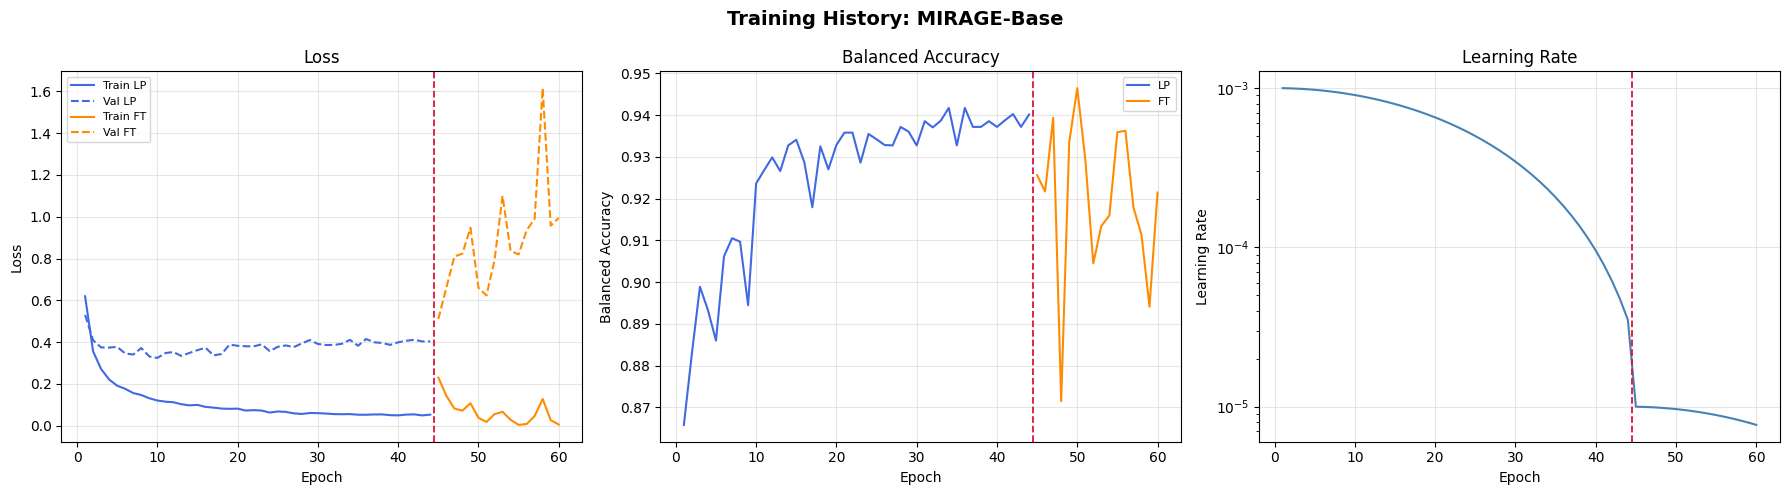

,Phase,Best Val BAcc,Best Val Loss,Epochs Run
0,Linear Probing,0.9417,0.411,44
1,Fine-Tuning,0.9465,0.660,16


In [23]:
n_lp  = len(history_lp['train_loss'])
n_ft  = len(history_ft['train_loss'])
ep_lp = range(1, n_lp + 1)
ep_ft = range(n_lp + 1, n_lp + n_ft + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History: MIRAGE-Base', fontsize=14, fontweight='bold')

for ax, key, ylabel in zip(axes,
                           ['train_loss', 'val_bacc', 'lr'],
                           ['Loss', 'Balanced Accuracy', 'Learning Rate']):
    val_key = key.replace('train_', 'val_') if 'train_' in key else key

    if key == 'lr':
        lr_all = history_lp['lr'] + history_ft['lr']
        ax.plot(range(1, len(lr_all) + 1), lr_all, color='steelblue')
        ax.set_yscale('log')
    elif key == 'train_loss':
        ax.plot(ep_lp, history_lp['train_loss'], label='Train LP', color='royalblue')
        ax.plot(ep_lp, history_lp['val_loss'],   label='Val LP',   color='royalblue', linestyle='--')
        ax.plot(ep_ft, history_ft['train_loss'], label='Train FT', color='darkorange')
        ax.plot(ep_ft, history_ft['val_loss'],   label='Val FT',   color='darkorange', linestyle='--')
        ax.legend(fontsize=8)
    else:
        ax.plot(ep_lp, history_lp['val_bacc'], label='LP', color='royalblue')
        ax.plot(ep_ft, history_ft['val_bacc'], label='FT', color='darkorange')
        ax.legend(fontsize=8)

    ax.axvline(n_lp + 0.5, color='crimson', linestyle='--', linewidth=1.3, label='Unfreeze')
    ax.set_title(ylabel)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'Phase':          ['Linear Probing', 'Fine-Tuning'],
    'Best Val BAcc':  [round(early_stop.best, 4),    round(early_stop_ft.best, 4)],
    'Best Val Loss':  [round(best_val_loss_lp, 4),   round(best_val_loss_ft, 4)],
    'Epochs Run':     [n_lp, n_ft]
})
display(summary_df)

---
&nbsp;

## **7. Test Set Evaluation**

In [24]:
_, _, _, y_true, y_pred, y_probs = eval_epoch(model, test_loader, criterion)
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

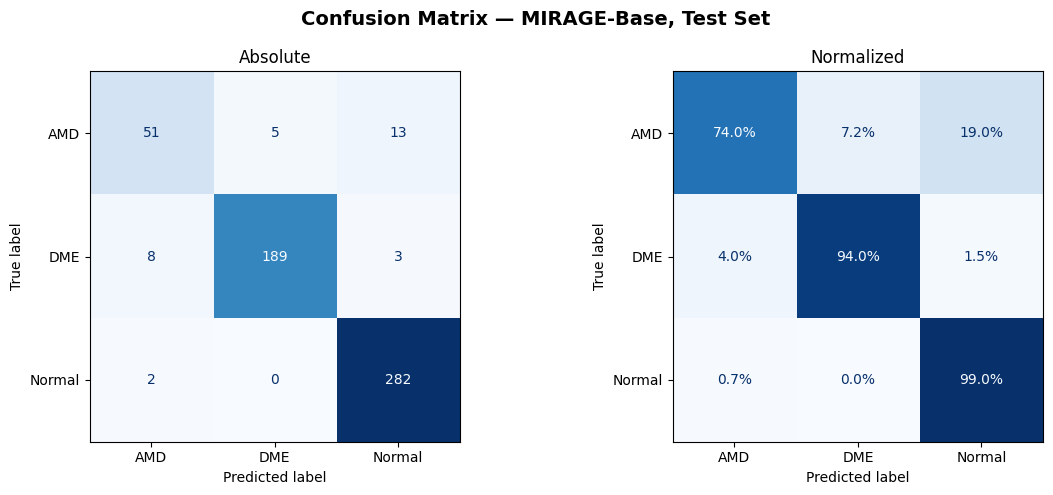

In [25]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — MIRAGE-Base, Test Set', fontsize=14, fontweight='bold')

cm      = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Absolute')

ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Normalized')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.1%}')

plt.tight_layout()
plt.show()

In [26]:
report    = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
ovr_auc   = roc_auc_score(y_bin, y_probs, multi_class='ovr', average='macro')
mcc_score = matthews_corrcoef(y_true, y_pred)
bacc_test = balanced_accuracy_score(y_true, y_pred)

rows = []
for i, cls in enumerate(class_names):
    auc_val = roc_auc_score(y_bin[:, i], y_probs[:, i])
    rows.append({
        'Class':     cls,
        'Precision': round(report[cls]['precision'], 3),
        'Recall':    round(report[cls]['recall'],    3),
        'F1-Score':  round(report[cls]['f1-score'],  3),
        'AUC':       round(auc_val, 3),
        'Support':   int(report[cls]['support']),
    })

macro = report['macro avg']
rows.append({
    'Class':     'macro avg',
    'Precision': round(macro['precision'], 3),
    'Recall':    round(macro['recall'],    3),
    'F1-Score':  round(macro['f1-score'],  3),
    'AUC':       round(ovr_auc, 3),
    'Support':   int(macro['support']),
})

df_metrics = pd.DataFrame(rows).set_index('Class')

print(f'Balanced Accuracy : {bacc_test:.4f}')
print(f'MCC               : {mcc_score:.4f}')

display(
    df_metrics.style
    .background_gradient(cmap='Blues',
                         subset=['Precision', 'Recall', 'F1-Score', 'AUC'],
                         vmin=0.5, vmax=1.0)
    .format({'Precision': '{:.3f}', 'Recall': '{:.3f}',
             'F1-Score':  '{:.3f}', 'AUC':    '{:.3f}'})
    .set_caption('<b>Classification Metrics — MIRAGE-Base</b>')
)

Balanced Accuracy : 0.8924
MCC               : 0.9046


,Precision,Recall,F1-Score,AUC,Support
Class,,,,,
AMD,0.836,0.739,0.785,0.985,69
DME,0.974,0.945,0.959,0.998,200
Normal,0.946,0.993,0.969,0.997,284
macro avg,0.919,0.892,0.904,0.993,553


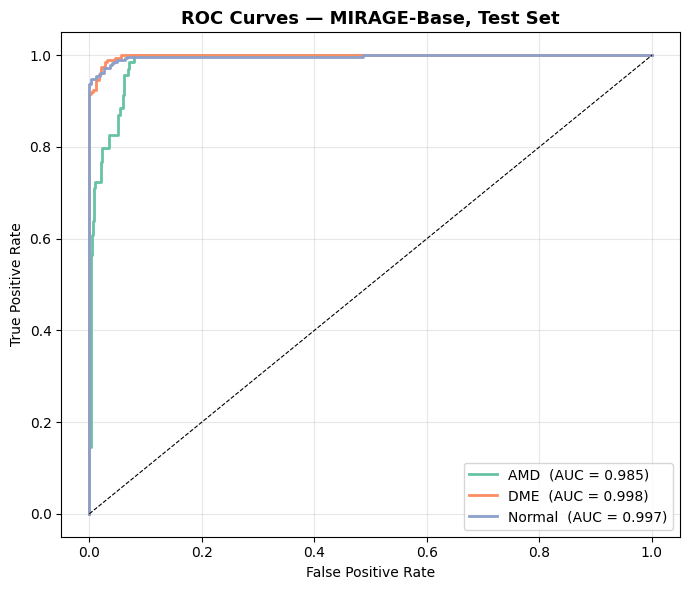

In [27]:
# ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('ROC Curves — MIRAGE-Base, Test Set', fontsize=13, fontweight='bold')

colors = sns.color_palette('Set2', NUM_CLASSES)
for i, (cls, col) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f'{cls}  (AUC = {auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

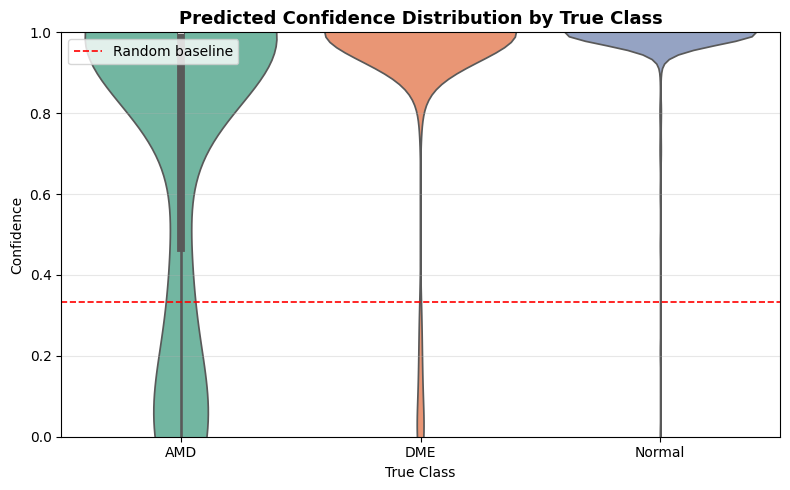

In [28]:
# Confidence Distribution by Class
conf_rows = []
for i, cls in enumerate(class_names):
    mask = y_true == i
    for prob in y_probs[mask, i]:
        conf_rows.append({'True Class': cls, 'Confidence': prob})

df_conf = pd.DataFrame(conf_rows)

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_conf, x='True Class', y='Confidence',
               palette='Set2', inner='box', ax=ax)
ax.axhline(1 / NUM_CLASSES, color='red', linestyle='--', linewidth=1.2,
           label='Random baseline')
ax.set_title('Predicted Confidence Distribution by True Class',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
&nbsp;

## **8. Explainability: Occlusion Sensitivity** 

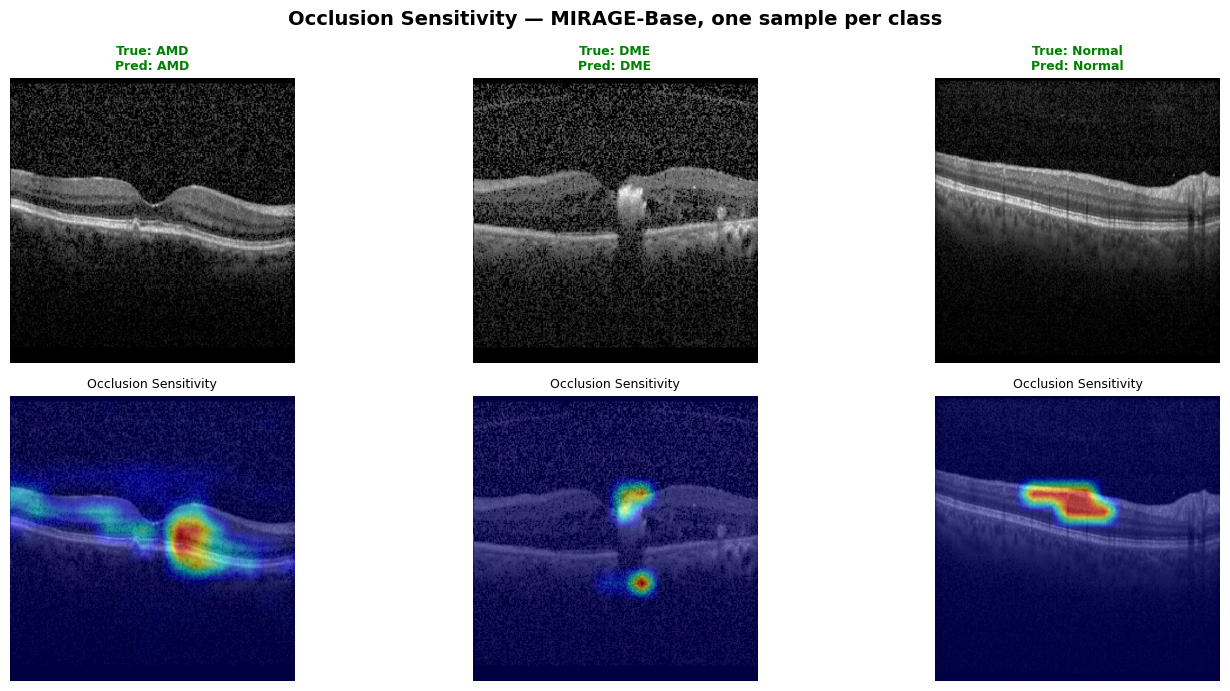

In [29]:
def occlusion_sensitivity(model, img_tensor, target_class,
                          patch_size=32, stride=32):
    model.eval()
    _, C, H, W = img_tensor.shape

    with torch.no_grad():
        base_prob = torch.softmax(model(img_tensor), dim=1)[0, target_class].item()

    h_steps = (H - patch_size) // stride + 1
    w_steps = (W - patch_size) // stride + 1
    sensitivity = np.zeros((h_steps, w_steps))

    for hi in range(h_steps):
        for wi in range(w_steps):
            y, x = hi * stride, wi * stride
            occluded = img_tensor.clone()
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0.0
            with torch.no_grad():
                prob = torch.softmax(model(occluded), dim=1)[0, target_class].item()
            sensitivity[hi, wi] = base_prob - prob  # drop = importanza

    sensitivity = np.maximum(sensitivity, 0)
    sensitivity = (sensitivity - sensitivity.min()) / (sensitivity.max() - sensitivity.min() + 1e-8)
    sensitivity = np.array(Image.fromarray(sensitivity).resize((W, H), Image.BILINEAR))
    return sensitivity


samples_by_class = {c: None for c in range(NUM_CLASSES)}
model.eval()

for imgs, labels in test_loader:
    for i in range(len(imgs)):
        cls = labels[i].item()
        if samples_by_class[cls] is None:
            samples_by_class[cls] = (imgs[i], labels[i])
    if all(v is not None for v in samples_by_class.values()):
        break

# Plot
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 7))
fig.suptitle('Occlusion Sensitivity — MIRAGE-Base, one sample per class',
             fontsize=14, fontweight='bold')

for col, cls_idx in enumerate(range(NUM_CLASSES)):
    img_t, label = samples_by_class[cls_idx]
    img_tensor   = img_t.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_idx = model(img_tensor).argmax(dim=1).item()

    sens    = occlusion_sensitivity(model, img_tensor, target_class=cls_idx)
    img_np  = img_t.squeeze().numpy()
    img_rgb = np.stack([img_np] * 3, axis=-1).astype(np.float32)
    vis     = show_cam_on_image(img_rgb, sens, use_rgb=True)

    correct = pred_idx == cls_idx
    color   = 'green' if correct else 'red'

    axes[0, col].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(
        f'True: {inverse_mapping[cls_idx]}\nPred: {inverse_mapping[pred_idx]}',
        fontsize=9, color=color, fontweight='bold'
    )
    axes[0, col].axis('off')

    axes[1, col].imshow(vis)
    axes[1, col].set_title('Occlusion Sensitivity', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

-------------------

## **9. Out-Of-Distribution (OOD) Detection & Calibration**

Glaucoma OOD images: 100

MIRAGE — Glaucoma OOD predictions:
  AMD       :  94  (94.0%)
  DME       :   5  (5.0%)
  Normal    :   1  (1.0%)
  Mean max confidence : 0.971
  Flagged uncertain   : 1/100  [threshold=0.65]


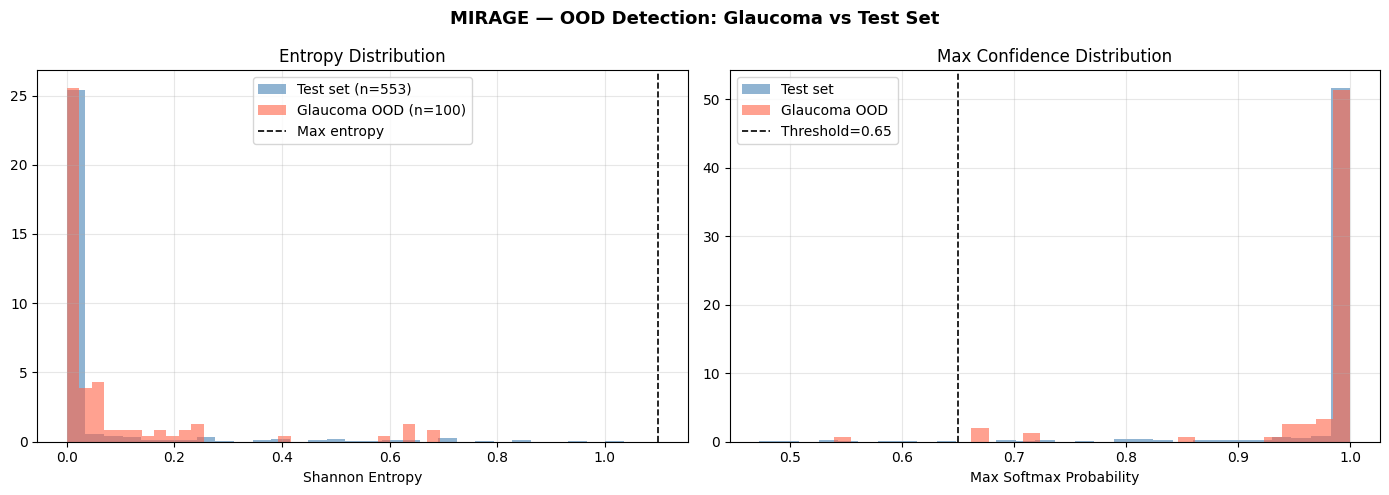

In [37]:
GLAUCOMA_DIR  = '/kaggle/input/datasets/susannamazzocchi/dataset-glaucoma/glaucoma_dataset'
OOD_THRESHOLD = 0.65
import scipy.stats

glaucoma_imgs = sorted(
    glob.glob(GLAUCOMA_DIR + '/*.jpg') +
    glob.glob(GLAUCOMA_DIR + '/*.png') +
    glob.glob(GLAUCOMA_DIR + '/*.jpeg')
)
glaucoma_imgs = random.sample(glaucoma_imgs, 100)
print(f'Glaucoma OOD images: {len(glaucoma_imgs)}')


class OODDatasetMIRAGE(Dataset):
    def __init__(self, img_paths):
        self.paths = img_paths
        self.norm  = MinMaxNorm()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        img = img.resize((512, 512), Image.Resampling.LANCZOS)
        x   = torch.tensor(np.array(img, dtype=np.float32) / 255.0).unsqueeze(0)
        return self.norm(x)


ood_dataset = OODDatasetMIRAGE(glaucoma_imgs)
ood_loader  = DataLoader(ood_dataset, batch_size=16, shuffle=False,
                         num_workers=2, pin_memory=True)

# Forward pass
model.eval()
all_probs_ood = []
with torch.no_grad():
    for imgs in ood_loader:
        imgs    = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs_ood.append(probs)

probs_ood    = np.vstack(all_probs_ood)
preds_ood    = probs_ood.argmax(axis=1)
max_conf_ood = probs_ood.max(axis=1)

print(f'\nMIRAGE — Glaucoma OOD predictions:')
for i, cls in enumerate(class_names):
    count = (preds_ood == i).sum()
    print(f'  {cls:10s}: {count:3d}  ({count/len(preds_ood)*100:.1f}%)')
print(f'  Mean max confidence : {max_conf_ood.mean():.3f}')
print(f'  Flagged uncertain   : {(max_conf_ood < OOD_THRESHOLD).sum()}/100'
      f'  [threshold={OOD_THRESHOLD}]')

# Entropy scoring
ent_ood  = scipy.stats.entropy(probs_ood,  axis=1)
ent_test = scipy.stats.entropy(y_probs,    axis=1)  # dal test set sezione 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MIRAGE — OOD Detection: Glaucoma vs Test Set', fontsize=13, fontweight='bold')

axes[0].hist(ent_test, bins=30, alpha=0.6, color='steelblue', density=True,
             label=f'Test set (n={len(ent_test)})')
axes[0].hist(ent_ood,  bins=30, alpha=0.6, color='tomato',    density=True,
             label='Glaucoma OOD (n=100)')
axes[0].axvline(np.log(3), color='black', linestyle='--', linewidth=1.2,
                label='Max entropy')
axes[0].set_title('Entropy Distribution')
axes[0].set_xlabel('Shannon Entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_probs.max(axis=1), bins=30, alpha=0.6, color='steelblue',
             density=True, label='Test set')
axes[1].hist(max_conf_ood, bins=30, alpha=0.6, color='tomato',
             density=True, label='Glaucoma OOD')
axes[1].axvline(OOD_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
                label=f'Threshold={OOD_THRESHOLD}')
axes[1].set_title('Max Confidence Distribution')
axes[1].set_xlabel('Max Softmax Probability')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
print("Recomputing logits and labels from val_loader...")
model.eval()

all_logits_val = []
all_labels_val = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)

        all_logits_val.append(logits.cpu())
        all_labels_val.append(labels.cpu())

logits_val_t = torch.cat(all_logits_val)
labels_val_t = torch.cat(all_labels_val)

print("Done. The variables are now available in memory.")

Recomputing logits and labels from val_loader...
Done. The variables are now available in memory.


Optimal temperature: 3.727

After Temperature Scaling (T=3.727):
  Mean max confidence OOD : 0.762  (was 0.971)
  Flagged (thresh=0.65)   : 18/100  (were 1/100)


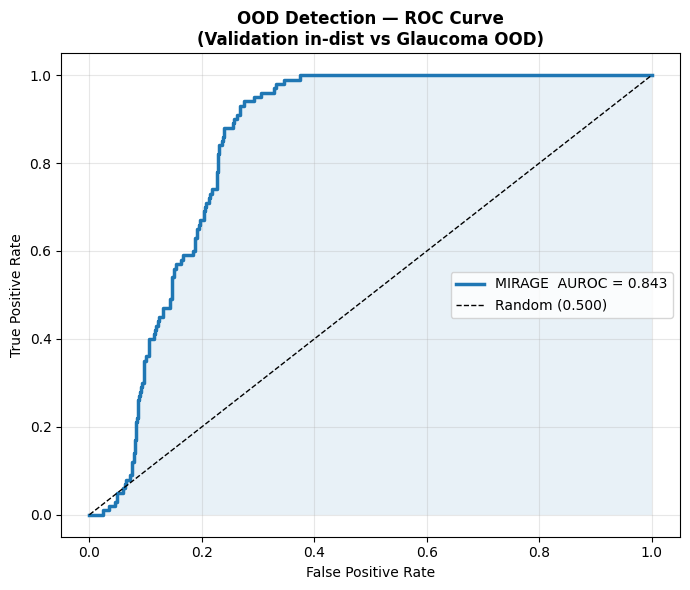


OOD AUROC (MIRAGE): 0.843


In [41]:
# Temperature scaling
def find_temperature_mirage(logits_val, labels_val, T_range=(0.5, 5.0), steps=100):
    best_T, best_nll = 1.0, float('inf')
    for T in np.linspace(T_range[0], T_range[1], steps):
        nll = nn.CrossEntropyLoss()(logits_val / T, labels_val).item()
        if nll < best_nll:
            best_nll, best_T = nll, T
    return best_T



T_opt = find_temperature_mirage(logits_val_t, labels_val_t)
print(f'Optimal temperature: {T_opt:.3f}')

probs_ood_cal  = torch.softmax(
    torch.tensor(probs_ood) / T_opt, dim=1).numpy()  # già numpy, riscaliamo
# ricalcolo corretto dai logits OOD
model.eval()
all_logits_ood = []
with torch.no_grad():
    for imgs in ood_loader:
        all_logits_ood.append(model(imgs.to(DEVICE)).cpu())
logits_ood_t   = torch.cat(all_logits_ood)
probs_ood_cal  = torch.softmax(logits_ood_t / T_opt, dim=1).numpy()
max_conf_cal   = probs_ood_cal.max(axis=1)
ent_ood_cal    = scipy.stats.entropy(probs_ood_cal, axis=1)

print(f'\nAfter Temperature Scaling (T={T_opt:.3f}):')
print(f'  Mean max confidence OOD : {max_conf_cal.mean():.3f}  (was {max_conf_ood.mean():.3f})')
print(f'  Flagged (thresh={OOD_THRESHOLD})   : {(max_conf_cal < OOD_THRESHOLD).sum()}/100'
      f'  (were {(max_conf_ood < OOD_THRESHOLD).sum()}/100)')

# OOD AUROC
probs_val_cal = torch.softmax(logits_val_t / T_opt, dim=1).numpy()
ent_val_cal   = scipy.stats.entropy(probs_val_cal, axis=1)

scores_auroc = np.concatenate([ent_val_cal, ent_ood_cal])
labels_auroc = np.concatenate([np.zeros(len(ent_val_cal)), np.ones(len(ent_ood_cal))])
auroc        = roc_auc_score(labels_auroc, scores_auroc)

fpr, tpr, _ = roc_curve(labels_auroc, scores_auroc)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2.5, label=f'MIRAGE  AUROC = {auroc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.10)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (0.500)')
ax.set_title('OOD Detection — ROC Curve\n(Validation in-dist vs Glaucoma OOD)',
             fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nOOD AUROC (MIRAGE): {auroc:.3f}')

In [42]:
# Temperature scaling
def find_temperature_mirage(logits_val, labels_val, T_range=(0.5, 5.0), steps=100):
    best_T, best_nll = 1.0, float('inf')
    for T in np.linspace(T_range[0], T_range[1], steps):
        nll = nn.CrossEntropyLoss()(logits_val / T, labels_val).item()
        if nll < best_nll:
            best_nll, best_T = nll, T
    return best_T

T_opt = find_temperature_mirage(logits_val_t, labels_val_t)
print(f'Optimal temperature: {T_opt:.3f}')

Optimal temperature: 3.727


-----------------------------------

## **10. Exporting Models & Predictions**

In [43]:
SAVE_DIR = '/kaggle/working/MIRAGE_OCT'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'class_mapping':    class_mapping,
    'class_names':      class_names,
    'history_lp':       history_lp,
    'history_ft':       history_ft,
    'val_bacc_lp':      early_stop.best,
    'val_bacc_ft':      early_stop_ft.best,
    'test_bacc':        bacc_test,
    'test_mcc':         mcc_score,
    'test_auc':         ovr_auc,
}, f'{SAVE_DIR}/MIRAGE_Base_OCT5k.pth')

print(f'Saved to {SAVE_DIR}/MIRAGE_Base_OCT5k.pth')
print(f'\nFinal Test Results:')
print(f'  Balanced Accuracy : {bacc_test:.4f}')
print(f'  Macro AUC (OvR)   : {ovr_auc:.4f}')
print(f'  MCC               : {mcc_score:.4f}')

Saved to /kaggle/working/MIRAGE_OCT/MIRAGE_Base_OCT5k.pth

Final Test Results:
  Balanced Accuracy : 0.8924
  Macro AUC (OvR)   : 0.9932
  MCC               : 0.9046


In [45]:
PRED_DIR_MIR = f"{SAVE_DIR}/predictions"
os.makedirs(PRED_DIR_MIR, exist_ok=True)

np.save(f"{PRED_DIR_MIR}/MIRAGE_y_true.npy", y_true)
np.save(f"{PRED_DIR_MIR}/MIRAGE_y_pred.npy", y_pred)
np.save(f"{PRED_DIR_MIR}/MIRAGE_y_probs.npy", y_probs)

model.eval()
with torch.no_grad():
    all_logits_val = []
    for imgs, _ in val_loader:
        all_logits_val.append(model(imgs.to(DEVICE)).cpu())

    logits_val_t = torch.cat(all_logits_val)
    probs_val_cal = torch.softmax(logits_val_t / T_opt, dim=1).numpy()

    all_logits_ood = []
    for imgs in ood_loader:
        all_logits_ood.append(model(imgs.to(DEVICE)).cpu())

    logits_ood_t = torch.cat(all_logits_ood)
    probs_ood_cal = torch.softmax(logits_ood_t / T_opt, dim=1).numpy()

ent_val_mir = scipy.stats.entropy(probs_val_cal, axis=1)
ent_ood_mir = scipy.stats.entropy(probs_ood_cal, axis=1)

np.save(f"{PRED_DIR_MIR}/MIRAGE_ent_val.npy", ent_val_mir)
np.save(f"{PRED_DIR_MIR}/MIRAGE_ent_ood.npy", ent_ood_mir)

meta_mir = {
    "class_names": class_names,
    "T_opt": float(T_opt),
    "test_bacc": float(bacc_test),
    "test_auc": float(ovr_auc),
    "test_mcc": float(mcc_score),
}

with open(f"{PRED_DIR_MIR}/meta.json", "w") as f:
    json.dump(meta_mir, f, indent=2)

print(f"All files saved to {PRED_DIR_MIR}")

for fname in sorted(os.listdir(PRED_DIR_MIR)):
    size = os.path.getsize(f"{PRED_DIR_MIR}/{fname}") / 1e3
    print(f"  {fname:<45} {size:6.1f} KB")

All files saved to /kaggle/working/MIRAGE_OCT/predictions
  MIRAGE_ent_ood.npy                               0.5 KB
  MIRAGE_ent_val.npy                               2.5 KB
  MIRAGE_y_pred.npy                                4.6 KB
  MIRAGE_y_probs.npy                               6.8 KB
  MIRAGE_y_true.npy                                4.6 KB
  meta.json                                        0.2 KB
